Optimization converged: True,  final loss: 28.5207
Computing Hessian for Laplace approximation...


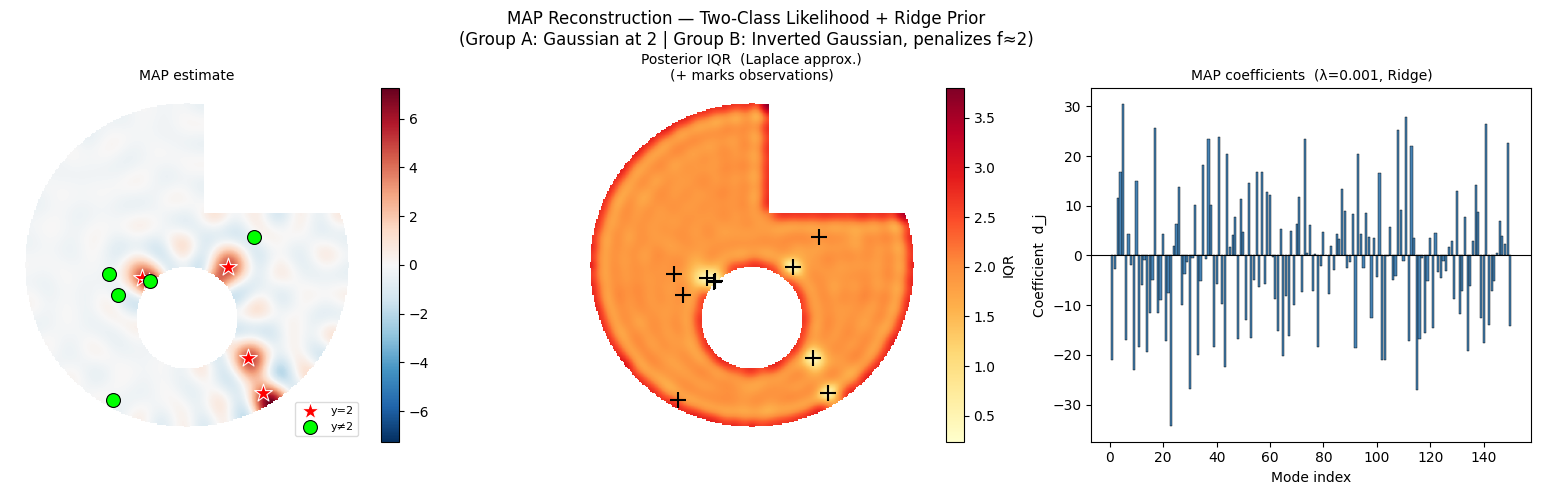

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import minimize

# ── 1. Build irregular domain ─────────────────────────────────────────────
N = 256
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
XX, YY = np.meshgrid(x, y)

mask = (
    (XX**2 + YY**2 < 0.85)
    & ~((XX > 0.1) & (YY > 0.3))
    & ~(XX**2 + (YY+0.3)**2 < 0.08)
)

pixels = np.argwhere(mask)
M = len(pixels)
idx_map = {(r, c): i for i, (r, c) in enumerate(pixels)}

# ── 2. Build sparse graph Laplacian (4-neighbor) ──────────────────────────
rows, cols, vals = [], [], []
for i, (r, c) in enumerate(pixels):
    degree = 0
    for (nr, nc) in [(r-1,c),(r+1,c),(r,c-1),(r,c+1)]:
        if (nr, nc) in idx_map:
            j = idx_map[(nr, nc)]
            rows.append(i); cols.append(j); vals.append(-1.0)
            degree += 1
    rows.append(i); cols.append(i); vals.append(float(degree))

L = sp.csr_matrix((vals, (rows, cols)), shape=(M, M))

# ── 3. Compute R2 smoothest eigenmodes ────────────────────────────────────
R2 = 150
eigenvalues, Phi = spla.eigsh(L, k=R2+1, which='SM')
order = np.argsort(eigenvalues)
eigenvalues = eigenvalues[order][1:]
Phi = Phi[:, order][:, 1:]             # (M, R2)

# ── 4. Generate 10 random observation points ──────────────────────────────
np.random.seed(42)
n_obs = 10
chosen_idx = np.random.choice(M, n_obs, replace=False)
chosen = pixels[chosen_idx]            # (10, 2)

# First 5 → "is 2",  last 5 → "is not 2"
group_A = np.arange(5)      # indices where y = 2
group_B = np.arange(5, 10)  # indices where y ≠ 2

obs_node_idx = [idx_map[(r, c)] for r, c in chosen]
A = Phi[obs_node_idx, :]               # (n_obs, R2)

# ── 5. Two-class likelihood + Ridge prior ────────────────────────────────
sigma2 = 0.1
lam    = 0.001
eps    = 1e-10   # numerical safety for log
val    = 5
def neg_log_likelihood(d):
    f = A @ d                          # predicted values at obs locations

    # Group A: Gaussian centered at 2 — penalizes f ≠ 2
    nll_A = 0.5 / sigma2 * np.sum((f[group_A] - val)**2)

    # Group B: Inverted Gaussian — penalizes f ≈ 2, rewards f far from 2
    #   -log p = -log(1 - exp(-(f-val)²/2σ²))
    sq_dist = 0.5 / sigma2 * (f[group_B] - val)**2
    nll_B   = -np.sum(np.log(1.0 - np.exp(-sq_dist) + eps))

    return nll_A + nll_B

def prior_ridge(d):
    return lam * np.dot(d, d)

def neg_log_posterior(d):
    return neg_log_likelihood(d) + prior_ridge(d)

# ── 6. Solve MAP via L-BFGS-B ─────────────────────────────────────────────
d0 = np.zeros(R2)
result = minimize(neg_log_posterior, d0, method='L-BFGS-B',
                  options={'maxiter': 5000, 'ftol': 1e-14})
d_map = result.x
print(f"Optimization converged: {result.success},  final loss: {result.fun:.4f}")

# ── 7. Posterior covariance via numerical Hessian (finite differences) ────
# NOTE: Because Group B likelihood is non-quadratic, the posterior is no
# longer exactly Gaussian. We use a Laplace approximation:
#   Sigma_post ≈ H^{-1}  where H = ∇²(-log posterior) at d_map
from scipy.optimize import approx_fprime
def hessian_fd(f, x0, eps_fd=1e-5):
    n = len(x0)
    H = np.zeros((n, n))
    grad0 = approx_fprime(x0, f, eps_fd)
    for i in range(n):
        x1 = x0.copy(); x1[i] += eps_fd
        grad1 = approx_fprime(x1, f, eps_fd)
        H[i] = (grad1 - grad0) / eps_fd
    return 0.5 * (H + H.T)   # symmetrize

print("Computing Hessian for Laplace approximation...")
H_mat = hessian_fd(neg_log_posterior, d_map)
Sigma_post = np.linalg.inv(H_mat)          # (R2, R2)

# Pointwise posterior variance: Var(f(x)) = Phi(x)ᵀ Sigma_post Phi(x)
PhiS     = Phi @ Sigma_post
post_var = np.sum(PhiS * Phi, axis=1)      # (M,)
post_std = np.sqrt(np.clip(post_var, 0, None))
post_iqr = 1.3490 * post_std               # IQR = 1.349 * std for Gaussian

# ── 8. Map results back to 2D grids ──────────────────────────────────────
def to_2d(vec):
    grid = np.full((N, N), np.nan)
    for i, (r, c) in enumerate(pixels):
        grid[r, c] = vec[i]
    return grid

field_2d = to_2d(Phi @ d_map)
iqr_2d   = to_2d(post_iqr)

# ── 9. Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "MAP Reconstruction — Two-Class Likelihood + Ridge Prior\n"
    "(Group A: Gaussian at 2 | Group B: Inverted Gaussian, penalizes f≈2)",
    fontsize=12)

# Panel 1: MAP field
ax = axes[0]
vmax = max(abs(np.nanmin(field_2d)), abs(np.nanmax(field_2d)))
im = ax.imshow(field_2d, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for k in range(n_obs):
    r, c = chosen[k]
    if k in group_A:
        ax.scatter(c, r, c='red',  marker='*', s=180, zorder=5,
                   edgecolors='white', linewidths=0.8, label='y=2' if k==0 else '')
    else:
        ax.scatter(c, r, c='lime', marker='o', s=100, zorder=5,
                   edgecolors='black', linewidths=0.8, label='y≠2' if k==5 else '')
ax.legend(loc='lower right', fontsize=8, framealpha=0.7)
ax.set_title("MAP estimate", fontsize=10)
ax.axis('off')

# Panel 2: Posterior IQR
ax = axes[1]
im2 = ax.imshow(iqr_2d, origin='lower', cmap='YlOrRd')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04, label='IQR')
for k in range(n_obs):
    r, c = chosen[k]
    ax.scatter(c, r, c='black', marker='+', s=120, zorder=5, linewidths=1.5)
ax.set_title("Posterior IQR  (Laplace approx.)\n(+ marks observations)", fontsize=10)
ax.axis('off')

# Panel 3: MAP coefficients
ax = axes[2]
ax.bar(np.arange(1, R2+1), d_map, color='steelblue', edgecolor='k', linewidth=0.3)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel("Mode index")
ax.set_ylabel("Coefficient  d_j")
ax.set_title(f"MAP coefficients  (λ={lam}, Ridge)", fontsize=10)

plt.tight_layout()
plt.show()